<a href="https://colab.research.google.com/github/Ghanshyammali10/DevMavericks_Coderush1.0/blob/main/FCNNipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Step 1: Import Keras
from tensorflow import keras

# Step 2: Dataset load karo (train aur test dono milte hain)
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

# Step 3: Basic info print karo
print("Training data shape:", x_train.shape)
print("Training labels shape:", y_train.shape)
print("Testing data shape:", x_test.shape)
print("Testing labels shape:", y_test.shape)

# Step 4: Class names (for reference)
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]
print("Fashion MNIST classes:", class_names)


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 28, 28)
Training labels shape: (60000,)
Testing data shape: (10000, 28, 28)
Testing labels shape: (10000,)
Fashion MNIST classes: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


In [2]:
import os
import datetime
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, utils, models
import matplotlib.pyplot as plt
from sklearn.utils import class_weight


In [3]:
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [4]:
os.makedirs("/content/tb_logs", exist_ok=True)
os.makedirs("/content/models", exist_ok=True)


In [5]:
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

print("Training images:", x_train.shape)
print("Training labels:", y_train.shape)
print("Test images:", x_test.shape)
print("Test labels:", y_test.shape)
print("Unique labels:", np.unique(y_train))


Training images: (60000, 28, 28)
Training labels: (60000,)
Test images: (10000, 28, 28)
Test labels: (10000,)
Unique labels: [0 1 2 3 4 5 6 7 8 9]


In [6]:
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]


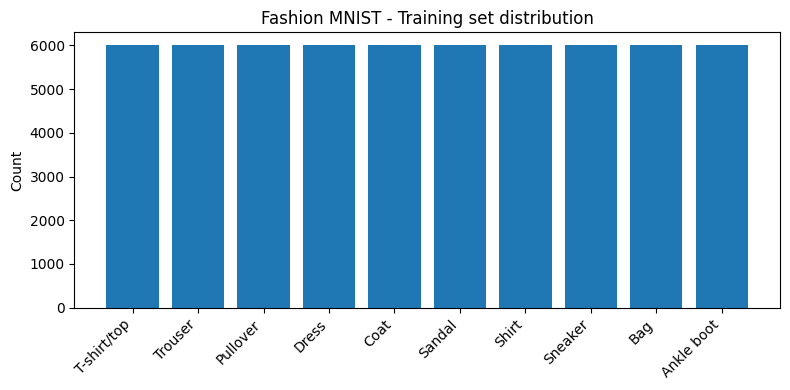

In [7]:
counts = {i: int(np.sum(y_train == i)) for i in range(10)}
plt.figure(figsize=(8,4))
plt.bar(range(10), [counts[i] for i in range(10)])
plt.xticks(range(10), class_names, rotation=45, ha='right')
plt.title("Fashion MNIST - Training set distribution")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [8]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

num_pixels = 28 * 28
x_train_flat = x_train.reshape((-1, num_pixels))
x_test_flat = x_test.reshape((-1, num_pixels))

num_classes = 10
y_train_ohe = utils.to_categorical(y_train, num_classes)
y_test_ohe = utils.to_categorical(y_test, num_classes)

print("Flattened train shape:", x_train_flat.shape)
print("One-hot labels shape:", y_train_ohe.shape)

Flattened train shape: (60000, 784)
One-hot labels shape: (60000, 10)


In [9]:
class_weights_vals = class_weight.compute_class_weight("balanced", classes=np.unique(y_train), y=y_train)
class_weights_dict = {i: float(class_weights_vals[i]) for i in range(len(class_weights_vals))}
print("Class weights:", class_weights_dict)


Class weights: {0: 1.0, 1: 1.0, 2: 1.0, 3: 1.0, 4: 1.0, 5: 1.0, 6: 1.0, 7: 1.0, 8: 1.0, 9: 1.0}


In [10]:
def build_fcnn(input_dim, num_classes, dropout_rate=0.4):
    model = models.Sequential(name="FCNN_Fashion_MNIST")
    model.add(layers.Input(shape=(input_dim,)))
    model.add(layers.Dense(512, activation="relu"))
    model.add(layers.Dropout(dropout_rate))
    model.add(layers.Dense(256, activation="relu"))
    model.add(layers.Dropout(dropout_rate))
    model.add(layers.Dense(128, activation="relu"))
    model.add(layers.Dropout(dropout_rate/2))
    model.add(layers.Dense(num_classes, activation="softmax"))
    return model

In [11]:
model = build_fcnn(num_pixels, num_classes, dropout_rate=0.4)
model.summary()


Model: "FCNN_Fashion_MNIST"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 567,434 (2.16 MB)

 Trainable params: 567,434 (2.16 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
learning_rate = 0.01
sgd = keras.optimizers.SGD(learning_rate=learning_rate, momentum=0.9)
model.compile(optimizer=sgd, loss="categorical_crossentropy", metrics=["accuracy"])


In [13]:
timestamp = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tb_log_dir = f"/content/tb_logs/fashion_mnist_fcnn_{timestamp}"
os.makedirs(tb_log_dir, exist_ok=True)

tensorboard_cb = callbacks.TensorBoard(log_dir=tb_log_dir, histogram_freq=1)
earlystop_cb = callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True)
checkpoint_path = f"/content/models/fashion_mnist_fcnn_best_{timestamp}.h5"
mc_cb = callbacks.ModelCheckpoint(checkpoint_path, monitor="val_loss", save_best_only=True)


In [14]:
epochs = 12
batch_size = 128
validation_split = 0.1

In [15]:
history = model.fit(
    x_train_flat, y_train_ohe,
    validation_split=validation_split,
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[tensorboard_cb, earlystop_cb, mc_cb],
    class_weight=class_weights_dict,
    verbose=2
)


Epoch 1/12


422/422 - 7s - 16ms/step - accuracy: 0.6965 - loss: 0.8360 - val_accuracy: 0.8260 - val_loss: 0.4745
Epoch 2/12


422/422 - 6s - 15ms/step - accuracy: 0.8104 - loss: 0.5310 - val_accuracy: 0.8413 - val_loss: 0.4252
Epoch 3/12


422/422 - 5s - 13ms/step - accuracy: 0.8311 - loss: 0.4705 - val_accuracy: 0.8560 - val_loss: 0.3880
Epoch 4/12


422/422 - 6s - 14ms/step - accuracy: 0.8436 - loss: 0.4363 - val_accuracy: 0.8628 - val_loss: 0.3743
Epoch 5/12


...

422/422 - 5s - 12ms/step - accuracy: 0.8661 - loss: 0.3717 - val_accuracy: 0.8770 - val_loss: 0.3418
Epoch 9/12


422/422 - 13s - 31ms/step - accuracy: 0.8666 - loss: 0.3674 - val_accuracy: 0.8815 - val_loss: 0.3316
Epoch 10/12


422/422 - 7s - 17ms/step - accuracy: 0.8714 - loss: 0.3548 - val_accuracy: 0.8812 - val_loss: 0.3260
Epoch 11/12


422/422 - 5s - 12ms/step - accuracy: 0.8745 - loss: 0.3445 - val_accuracy: 0.8817 - val_loss: 0.3251
Epoch 12/12


422/422 - 6s - 15ms/step - accuracy: 0.8738 - loss: 0.3440 - val_accuracy: 0.8858 - val_loss: 0.3235


In [17]:
final_model_path = f"/content/models/fashion_mnist_fcnn_final_{timestamp}.h5"
model.save(final_model_path)
print("Saved final model to:", final_model_path)
print("Saved best model (checkpoint) to:", checkpoint_path)
print("TensorBoard logs:", tb_log_dir)


Saved final model to: /content/models/fashion_mnist_fcnn_final_20251011-145927.h5
Saved best model (checkpoint) to: /content/models/fashion_mnist_fcnn_best_20251011-145927.h5
TensorBoard logs: /content/tb_logs/fashion_mnist_fcnn_20251011-145927


In [18]:
test_loss, test_acc = model.evaluate(x_test_flat, y_test_ohe, verbose=2)
print(f"Test loss: {test_loss:.4f}, Test accuracy: {test_acc:.4f}")


313/313 - 1s - 3ms/step - accuracy: 0.8714 - loss: 0.3513
Test loss: 0.3513, Test accuracy: 0.8714


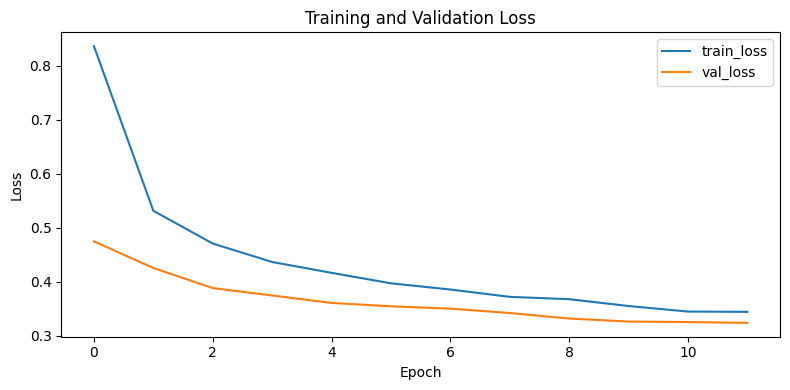

In [22]:
plt.figure(figsize=(8,4))
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()




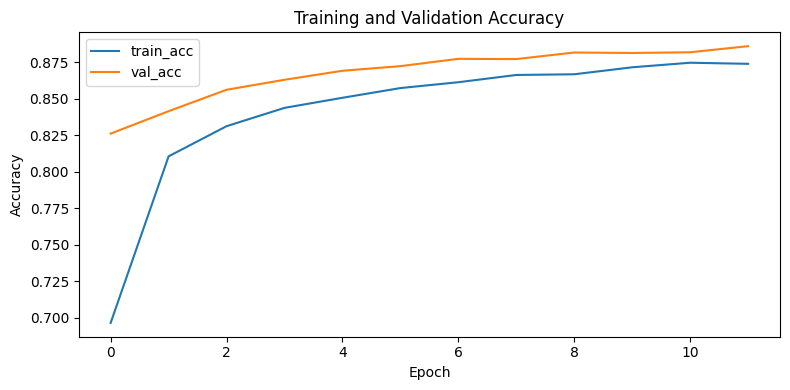

In [21]:
plt.figure(figsize=(8,4))
plt.plot(history.history["accuracy"], label="train_acc")
plt.plot(history.history["val_accuracy"], label="val_acc")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step


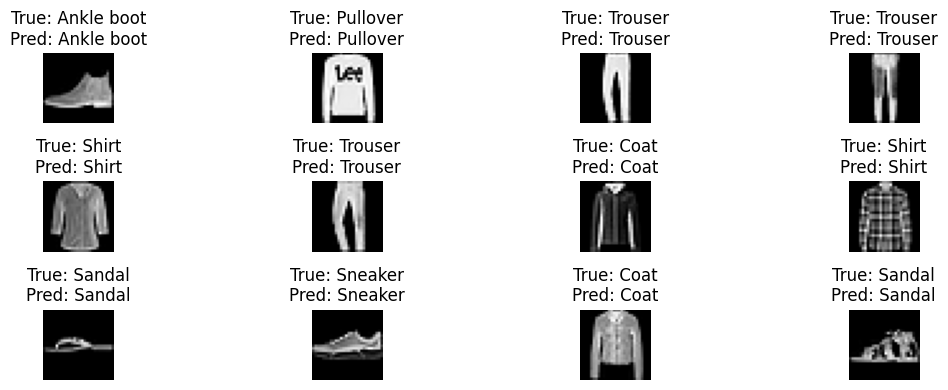

In [23]:
preds = model.predict(x_test_flat[:12])
pred_labels = np.argmax(preds, axis=1)
true_labels = y_test[:12]

plt.figure(figsize=(12,4))
for i in range(12):
    plt.subplot(3,4,i+1)
    plt.imshow(x_test[i], cmap="gray")
    plt.title(f"True: {class_names[true_labels[i]]}\nPred: {class_names[pred_labels[i]]}")
    plt.axis("off")
plt.tight_layout()
plt.show()

In [24]:
report = {
    "train_samples": int(x_train_flat.shape[0]),
    "test_samples": int(x_test_flat.shape[0]),
    "num_classes": num_classes,
    "epochs_run": len(history.history["loss"]),
    "final_train_loss": float(history.history["loss"][-1]),
    "final_val_loss": float(history.history["val_loss"][-1]),
    "final_train_acc": float(history.history["accuracy"][-1]),
    "final_val_acc": float(history.history["val_accuracy"][-1]),
    "test_loss": float(test_loss),
    "test_acc": float(test_acc),
    "model_path": final_model_path,
    "best_model_path": checkpoint_path,
    "tensorboard_logdir": tb_log_dir
}

In [25]:
print("\nQuick Report Summary:")
for k,v in report.items():
    print(f"{k}: {v}")



Quick Report Summary:
train_samples: 60000
test_samples: 10000
num_classes: 10
epochs_run: 12
final_train_loss: 0.34395691752433777
final_val_loss: 0.323525995016098
final_train_acc: 0.8737592697143555
final_val_acc: 0.8858333230018616
test_loss: 0.35129308700561523
test_acc: 0.871399998664856
model_path: /content/models/fashion_mnist_fcnn_final_20251011-145927.h5
best_model_path: /content/models/fashion_mnist_fcnn_best_20251011-145927.h5
tensorboard_logdir: /content/tb_logs/fashion_mnist_fcnn_20251011-145927


In [26]:
report_txt = "/content/fashion_mnist_fcnn_report.txt"
with open(report_txt, "w") as f:
    for k,v in report.items():
        f.write(f"{k}: {v}\n")
print("Saved textual report to:", report_txt)


Saved textual report to: /content/fashion_mnist_fcnn_report.txt
